### SUDOKU


In [ ]:
import os
import cv2
import numpy as np
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.model_selection import train_test_split

# === 1. Cargar y procesar imágenes ===
data_X = []
data_y = []

#data_path = r"D:/0-Markdown/ml/redes_neuronales/sudoku/archive/digits_updated/digits updated"
data_path = r"./archive/digits_updated/digits updated"

data_classes = len(os.listdir(data_path))

for i in range(data_classes):
    folder = os.path.join(data_path, str(i))
    for file in os.listdir(folder):
        img_path = os.path.join(folder, file)
        img = cv2.imread(img_path)
        img = cv2.resize(img, (32, 32))
        data_X.append(img)
        data_y.append(i)

data_X = np.array(data_X)
data_y = np.array(data_y)

print("Total datapoints =", len(data_X))

# === 2. Dividir dataset ===
train_X, test_X, train_y, test_y = train_test_split(data_X, data_y, test_size=0.05, random_state=42)
train_X, valid_X, train_y, valid_y = train_test_split(train_X, train_y, test_size=0.2, random_state=42)

# === 3. Preprocesamiento ===
def Prep(img):
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    img = cv2.equalizeHist(img)
    img = img.astype('float32') / 255.0
    return img

train_X = np.array([Prep(x) for x in train_X])
valid_X = np.array([Prep(x) for x in valid_X])
test_X = np.array([Prep(x) for x in test_X])

# Añadir canal para imágenes en escala de grises
train_X = train_X.reshape(-1, 32, 32, 1)
valid_X = valid_X.reshape(-1, 32, 32, 1)
test_X = test_X.reshape(-1, 32, 32, 1)

# === 4. Codificación One-Hot ===
train_y = to_categorical(train_y, num_classes=10)
valid_y = to_categorical(valid_y, num_classes=10)
test_y  = to_categorical(test_y, num_classes=10)

# === 5. Augmentación ===
datagen = ImageDataGenerator(
    width_shift_range=0.1, 
    height_shift_range=0.1, 
    zoom_range=0.2, 
    shear_range=0.1, 
    rotation_range=10
)
datagen.fit(train_X)

# === 6. Crear modelo ===
model = Sequential()
model.add(Conv2D(60, (5, 5), padding='same', activation='relu', input_shape=(32, 32, 1)))
model.add(Conv2D(60, (5, 5), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2)))

model.add(Conv2D(30, (3, 3), padding='same', activation='relu'))
model.add(Conv2D(30, (3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(pool_size=(2, 2), strides=(2, 2)))
model.add(Dropout(0.5))

model.add(Flatten())
model.add(Dense(500, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(10, activation='softmax'))

model.summary()

# === 7. Compilar modelo ===
optimizer = RMSprop(learning_rate=0.001, rho=0.9, epsilon=1e-08)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# === 8. Entrenar modelo ===
history = model.fit(
    datagen.flow(train_X, train_y, batch_size=32),
    epochs=30,
    validation_data=(valid_X, valid_y),
    steps_per_epoch=200,
    verbose=2
)

# === 9. Evaluar modelo ===
score = model.evaluate(test_X, test_y, verbose=1)
print("Test Score =", score[0])
print("Test Accuracy =", score[1])


Total datapoints = 10160


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_8 (Conv2D)               │ (None, 32, 32, 60)     │         1,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 32, 32, 60)     │        90,060 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 60)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 16, 16, 30)     │        16,230 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 16, 30)     │         8,130 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 30)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 30)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 1920)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 500)            │       960,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 500)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         5,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,081,490 (4.13 MB)

 Trainable params: 1,081,490 (4.13 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
200/200 - 8s - 38ms/step - accuracy: 0.6612 - loss: 1.0072 - val_accuracy: 0.9694 - val_loss: 0.0978
Epoch 2/30
200/200 - 2s - 10ms/step - accuracy: 0.8940 - loss: 0.3371 - val_accuracy: 0.9808 - val_loss: 0.0615
Epoch 3/30
200/200 - 7s - 35ms/step - accuracy: 0.9131 - loss: 0.2723 - val_accuracy: 0.9845 - val_loss: 0.0482
Epoch 4/30
200/200 - 2s - 10ms/step - accuracy: 0.9390 - loss: 0.1666 - val_accuracy: 0.9819 - val_loss: 0.0490
Epoch 5/30
200/200 - 7s - 35ms/step - accuracy: 0.9435 - loss: 0.1798 - val_accuracy: 0.9948 - val_loss: 0.0209
Epoch 6/30
200/200 - 2s - 10ms/step - accuracy: 0.9613 - loss: 0.1295 - val_accuracy: 0.9819 - val_loss: 0.0690
Epoch 7/30
200/200 - 7s - 35ms/step - accuracy: 0.9561 - loss: 0.1387 - val_accuracy: 0.9891 - val_loss: 0.0289
Epoch 8/30
200/200 - 2s - 11ms/step - accuracy: 0.9524 - loss: 0.1485 - val_accuracy: 0.9927 - val_loss: 0.0185
Epoch 9/30
200/200 - 7s - 35ms/step - accuracy: 0.9583 - loss: 0.1342 - val_accuracy: 0.9927 - val_loss:

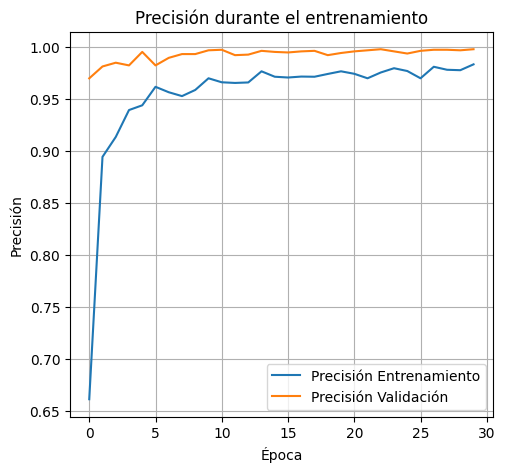

In [28]:
# === Precisión ===
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Precisión Entrenamiento')
plt.plot(history.history['val_accuracy'], label='Precisión Validación')
plt.title('Precisión durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.grid()

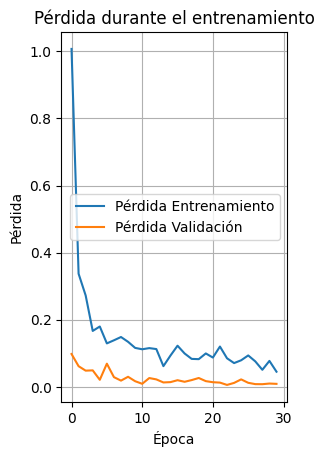

In [29]:
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Pérdida Entrenamiento')
plt.plot(history.history['val_loss'], label='Pérdida Validación')
plt.title('Pérdida durante el entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()
plt.grid()

In [30]:
model.save("modelo_digitos.h5")
